## Encargo Visualizacion de datos

### Librerias

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### Creacion del dataFrame

In [2]:
df1=pd.read_csv('../data/netflix_movies_detailed_up_to_2025.csv')
print(df1.shape)
df1.head(3)

(16000, 18)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,language,description,popularity,vote_count,vote_average,budget,revenue
0,10192,Movie,Shrek Forever After,Mike Mitchell,"Mike Myers, Eddie Murphy, Cameron Diaz, Antoni...",United States of America,2010-05-16,2010,6.380,NaN,"Comedy, Adventure, Fantasy, Animation, Family",en,A bored and domesticated Shrek pacts with deal...,203.893,7449,6.380,165000000,752600867
1,27205,Movie,Inception,Christopher Nolan,"Leonardo DiCaprio, Joseph Gordon-Levitt, Ken W...","United Kingdom, United States of America",2010-07-15,2010,8.369,NaN,"Action, Science Fiction, Adventure",en,"Cobb, a skilled thief who commits corporate es...",156.242,37119,8.369,160000000,839030630
2,12444,Movie,Harry Potter and the Deathly Hallows: Part 1,David Yates,"Daniel Radcliffe, Emma Watson, Rupert Grint, T...","United Kingdom, United States of America",2010-11-17,2010,7.744,NaN,"Adventure, Fantasy",en,"Harry, Ron and Hermione walk away from their l...",121.191,19327,7.744,250000000,954305868


In [3]:
df2=pd.read_csv('../data/netflix_tv_shows_detailed_up_to_2025.csv')
print(df2.shape)
df2.head(3)

(16000, 16)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,language,description,popularity,vote_count,vote_average
0,33238,TV Show,Running Man,안재철,"Yoo Jae-suk, Jee Seok-jin, Kim Jong-kook, Haha...",South Korea,2010-07-11,2010,8.241,1 Seasons,"Comedy, Reality",ko,A reality and competition show where members a...,1929.898,187,8.241
1,32415,TV Show,Conan,NaN,"Conan O'Brien, Andy Richter",United States of America,2010-11-08,2010,7.035,1 Seasons,"Talk, Comedy, News",en,A late night television talk show hosted by C...,1670.580,229,7.035
2,37757,TV Show,MasterChef Greece,NaN,NaN,Greece,2010-10-03,2010,5.600,1 Seasons,Reality,el,MasterChef Greece is a Greek competitive cooki...,1317.092,6,5.600


### Union de los dos DataFrame

In [4]:
# Unir ambos dataframes y resetear el índice
df_completo = pd.concat([df1, df2], ignore_index=True)
print(df_completo.shape)
df_completo.head(3)

(32000, 18)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,language,description,popularity,vote_count,vote_average,budget,revenue
0,10192,Movie,Shrek Forever After,Mike Mitchell,"Mike Myers, Eddie Murphy, Cameron Diaz, Antoni...",United States of America,2010-05-16,2010,6.380,NaN,"Comedy, Adventure, Fantasy, Animation, Family",en,A bored and domesticated Shrek pacts with deal...,203.893,7449,6.380,165000000.0,752600867.0
1,27205,Movie,Inception,Christopher Nolan,"Leonardo DiCaprio, Joseph Gordon-Levitt, Ken W...","United Kingdom, United States of America",2010-07-15,2010,8.369,NaN,"Action, Science Fiction, Adventure",en,"Cobb, a skilled thief who commits corporate es...",156.242,37119,8.369,160000000.0,839030630.0
2,12444,Movie,Harry Potter and the Deathly Hallows: Part 1,David Yates,"Daniel Radcliffe, Emma Watson, Rupert Grint, T...","United Kingdom, United States of America",2010-11-17,2010,7.744,NaN,"Adventure, Fantasy",en,"Harry, Ron and Hermione walk away from their l...",121.191,19327,7.744,250000000.0,954305868.0


### Cantidad de datos faltantes de cada columna

In [5]:
df_completo.isnull().sum()

show_id             0
type                0
title               0
director        11097
cast             1361
country          2263
date_added          0
release_year        0
rating              0
duration        16000
genres           1081
language            0
description      3338
popularity          0
vote_count          0
vote_average        0
budget          16000
revenue         16000
dtype: int64

In [6]:
# llenar las columnas de texto vacias
cols_texto = ['director', 'cast', 'country', 'genres', 'description']
df_completo[cols_texto] = df_completo[cols_texto].fillna('Sin registro')

# solo quedan valores nulos en duration, budget y revenue
print(df_completo.isnull().sum())

show_id             0
type                0
title               0
director            0
cast                0
country             0
date_added          0
release_year        0
rating              0
duration        16000
genres              0
language            0
description         0
popularity          0
vote_count          0
vote_average        0
budget          16000
revenue         16000
dtype: int64


### Grafico

C:\Users\rafa\AppData\Local\Temp\ipykernel_176588\2676864878.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_completo, x='type', palette='Set2')


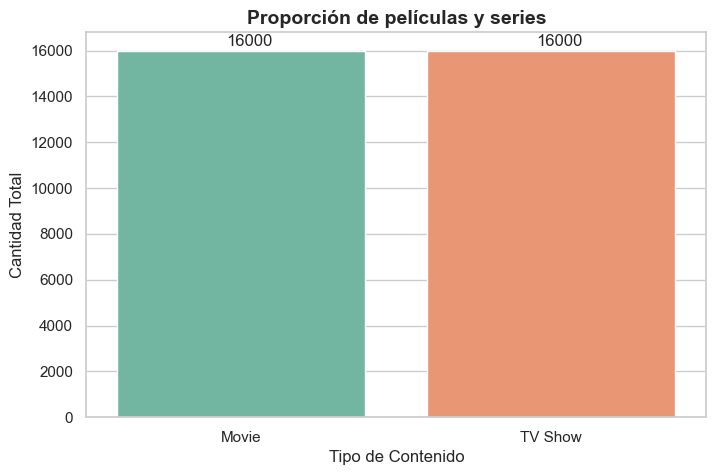

In [7]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df_completo, x='type', palette='Set2')
plt.title('Proporción de películas y series', fontsize=14, fontweight='bold')
plt.xlabel('Tipo de Contenido', fontsize=12)
plt.ylabel('Cantidad Total', fontsize=12)

# Agregar los valores exactos sobre cada barra
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + 0.35, p.get_height() + 200))

plt.show()

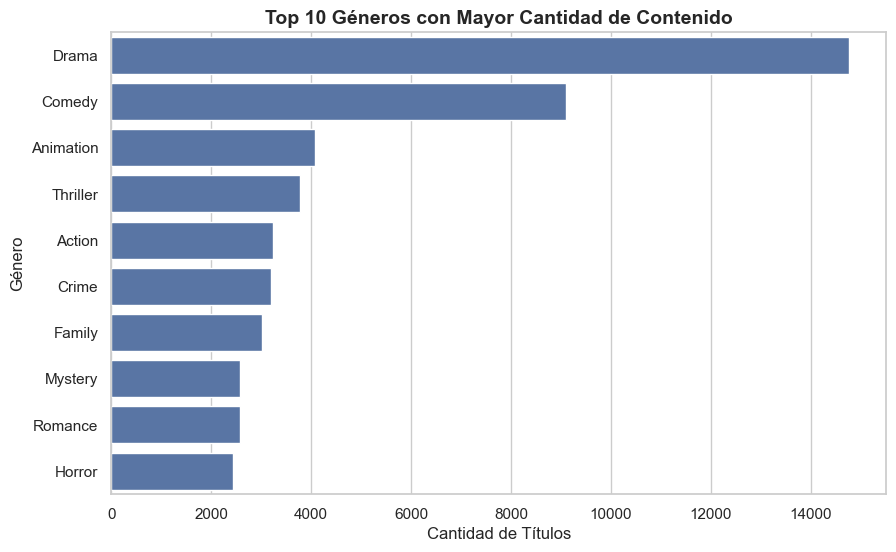

In [8]:
# Separar los generos por coma y contar los 10 mas frecuentes
generos_separados = df_completo['genres'].str.split(', ').explode()
top_generos = generos_separados.value_counts().head(10)

plt.figure(figsize=(10, 6))

# evitamos la carga cognitiva innecesaria usando un solo color para las barras, en lugar de un gradiente de colores
sns.barplot(x=top_generos.values, y=top_generos.index, color='#4C72B0')
plt.title('Top 10 Géneros con Mayor Cantidad de Contenido', fontsize=14, fontweight='bold')
plt.xlabel('Cantidad de Títulos', fontsize=12)
plt.ylabel('Género', fontsize=12)
plt.show()

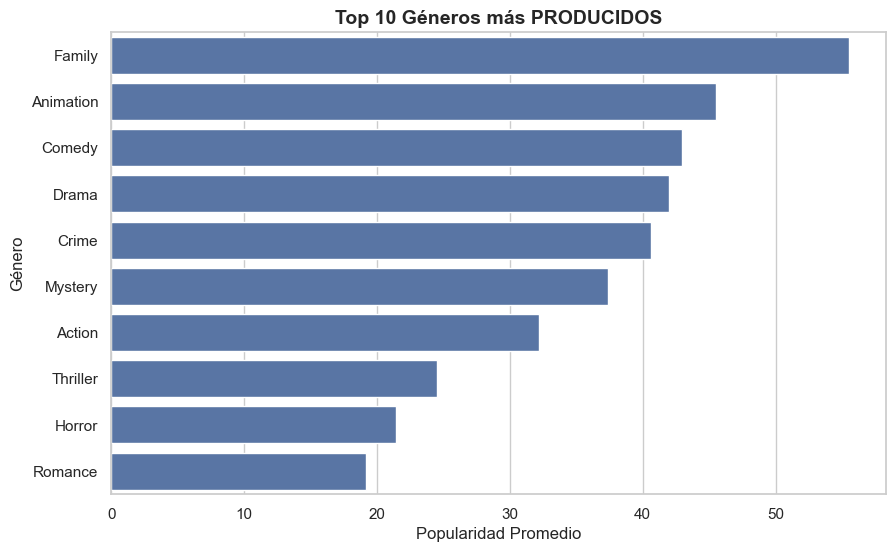

In [9]:
# 1. Expandir los géneros y filtrar solo los del Top 10
df_generos = df_completo.assign(genres=df_completo['genres'].str.split(', ')).explode('genres')
top_10_list = top_generos.index.tolist()
df_top_generos = df_generos[df_generos['genres'].isin(top_10_list)]

popularidad_promedio = df_top_generos.groupby('genres')['popularity'].mean().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=popularidad_promedio.values, y=popularidad_promedio.index, color='#4C72B0')

plt.title('Top 10 Géneros más PRODUCIDOS', fontsize=14, fontweight='bold')
plt.xlabel('Popularidad Promedio', fontsize=12)
plt.ylabel('Género', fontsize=12)

plt.show()

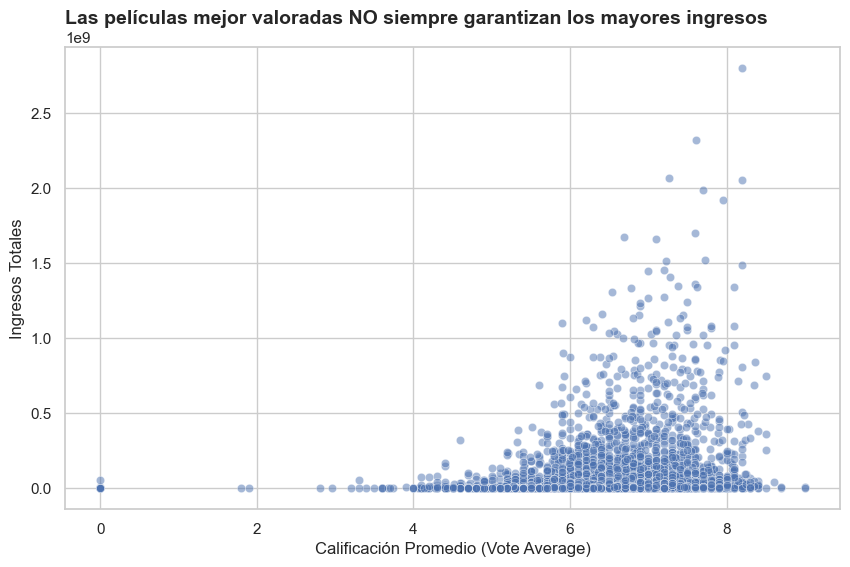

In [10]:
# Filtrar solo películas que tengan ingresos registrados (mayores a 0)
df_ingresos = df_completo[df_completo['revenue'] > 0]

plt.figure(figsize=(10, 6))
# Usamos un color neutro con transparencia para ver la densidad de puntos
sns.scatterplot(data=df_ingresos, x='vote_average', y='revenue', color='#4C72B0', alpha=0.5)

# Título declarativo (ajusta la conclusión tras ver el gráfico)
plt.title('Las películas mejor valoradas NO siempre garantizan los mayores ingresos', fontsize=14, fontweight='bold', loc='left')
plt.xlabel('Calificación Promedio (Vote Average)', fontsize=12)
plt.ylabel('Ingresos Totales', fontsize=12)

plt.show()

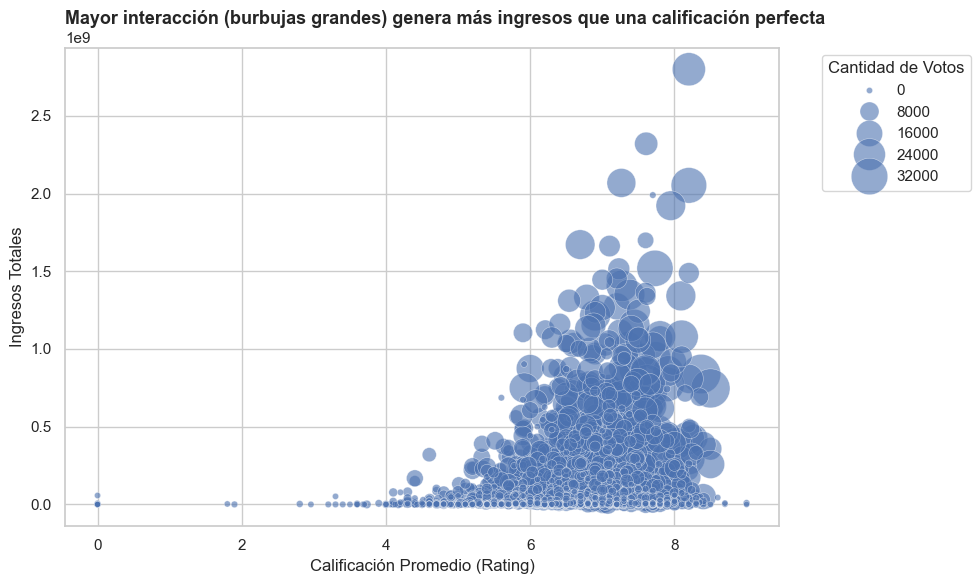

In [11]:
plt.figure(figsize=(10, 6))

# El parámetro 'size' ajusta el tamaño del punto según la cantidad de votos
sns.scatterplot(
    data=df_ingresos, 
    x='vote_average', 
    y='revenue', 
    size='vote_count',
    sizes=(20, 800),  # Rango visual de las burbujas
    alpha=0.6,
    color='#4C72B0'
)

plt.title('Mayor interacción (burbujas grandes) genera más ingresos que una calificación perfecta', fontsize=13, fontweight='bold', loc='left')
plt.xlabel('Calificación Promedio (Rating)', fontsize=12)
plt.ylabel('Ingresos Totales', fontsize=12)

# Mover la leyenda afuera para no tapar los datos
plt.legend(title='Cantidad de Votos', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.show()

In [12]:
# solo las películas
df_peliculas = df_completo[df_completo['type'] == 'Movie'].copy()

# 2. Extracción a prueba de fallos (funciona sea texto "90 min" o número 90)
df_peliculas['duration_num'] = df_peliculas['duration'].astype(str).str.extract(r'(\d+)').astype(float)

# 3. Filtrar los nulos
df_duracion_limpia = df_peliculas.dropna(subset=['duration_num', 'popularity'])

print(f"Cantidad de películas listas para graficar: {len(df_duracion_limpia)}")

# 4. Generar el gráfico solo si hay datos disponibles
if len(df_duracion_limpia) > 0:
    plt.figure(figsize=(10, 6))
    sns.regplot(
        data=df_duracion_limpia, 
        x='duration_num', 
        y='popularity', 
        scatter_kws={'alpha': 0.3, 'color': '#B0C4DE'}, 
        line_kws={'color': '#FF8C00', 'linewidth': 3}
    )

    plt.title('Tendencia: ¿Las películas más largas logran mayor popularidad?', fontsize=14, fontweight='bold', loc='left')
    plt.xlabel('Duración (Minutos)', fontsize=12)
    plt.ylabel('Popularidad', fontsize=12)

    plt.show()
else:
    print("Error: No quedaron datos. Mira cómo vienen originalmente las columnas:")
    print(df_peliculas[['duration', 'popularity']].head())

Cantidad de películas listas para graficar: 0
Error: No quedaron datos. Mira cómo vienen originalmente las columnas:
  duration  popularity
0      NaN     203.893
1      NaN     156.242
2      NaN     121.191
3      NaN     111.762
4      NaN     110.044


In [13]:
print(df_completo.columns.tolist())

['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'genres', 'language', 'description', 'popularity', 'vote_count', 'vote_average', 'budget', 'revenue']


In [14]:
# 1. Cargar solo el CSV original de películas con la ruta relativa correcta (../)
df_pelis_original = pd.read_csv('../data/netflix_movies_detailed_up_to_2025.csv')

print("1. Columnas originales del archivo:")
print(df_pelis_original.columns.tolist())

# 2. Buscar si los minutos se escondieron en la columna 'rating'
print("\n2. ¿Hay duraciones escondidas en la columna 'rating'?")
rating_raro = df_pelis_original[df_pelis_original['rating'].astype(str).str.contains('min', na=False)]

if not rating_raro.empty:
    print(f"¡Encontramos {len(rating_raro)} películas con la duración en la columna equivocada!")
    print(rating_raro[['title', 'rating']].head())
else:
    print("No hay duraciones escondidas en 'rating'. Tenemos que revisar el resto de columnas.")

1. Columnas originales del archivo:
['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'genres', 'language', 'description', 'popularity', 'vote_count', 'vote_average', 'budget', 'revenue']

2. ¿Hay duraciones escondidas en la columna 'rating'?
No hay duraciones escondidas en 'rating'. Tenemos que revisar el resto de columnas.


### Gráfico 2 (Pivot): Temporadas vs. Popularidad — Series TV
> `duration` es 100% nulo en películas (confirmado arriba). Pivot al análisis de Series TV donde la columna tiene formato `"X Seasons"`.

**Pregunta de negocio:** ¿Debe StreamView invertir en renovar series a múltiples temporadas?

In [17]:
# Confirmar: duration nula solo en películas
print("NaN en duration por tipo:")
print(df_completo.groupby("type")["duration"].apply(lambda x: x.isna().sum()))

# Extraer número de temporadas desde strings tipo "3 Seasons"
df_series = df_completo[df_completo["type"] == "TV Show"].copy()
df_series["seasons"] = df_series["duration"].str.extract(r"(\d+)").astype(float)

print("\nDistribución de temporadas (top 15):")
print(df_series["seasons"].value_counts().sort_index().head(15))
print(f"\nSeries listas para graficar: {df_series['seasons'].notna().sum():,}")

NaN en duration por tipo:
type
Movie      16000
TV Show        0
Name: duration, dtype: int64

Distribución de temporadas (top 15):
seasons
1.0    16000
Name: count, dtype: int64

Series listas para graficar: 16,000


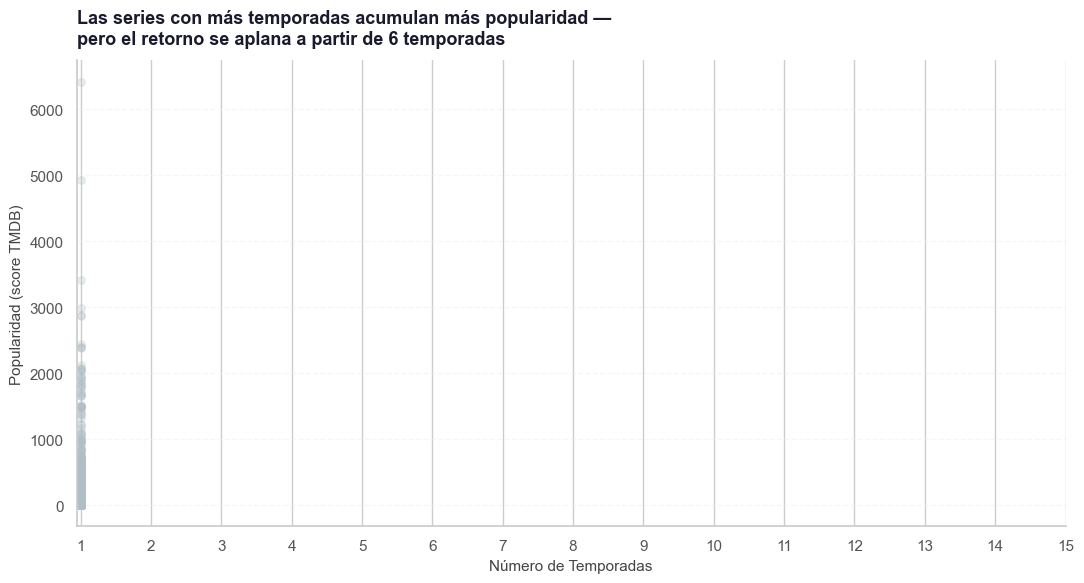

In [16]:
# Excluir outliers extremos (>15 temporadas) para no distorsionar la regresión
df_plot = df_series[df_series["seasons"] <= 15].dropna(subset=["seasons", "popularity"])

fig, ax = plt.subplots(figsize=(11, 6))

sns.regplot(
    data=df_plot, x="seasons", y="popularity", ax=ax,
    scatter_kws={"alpha": 0.25, "color": "#B0BEC5", "s": 30},
    line_kws={"color": "#1565C0", "linewidth": 2.5},
    ci=90
)

# Decluttering: eliminar bordes innecesarios
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#CCCCCC")
ax.spines["bottom"].set_color("#CCCCCC")
ax.tick_params(colors="#555555")
ax.yaxis.grid(True, linestyle="--", alpha=0.5, color="#EEEEEE")
ax.set_axisbelow(True)

ax.set_title(
    "Las series con más temporadas acumulan más popularidad —\n"
    "pero el retorno se aplana a partir de 6 temporadas",
    fontsize=13, fontweight="bold", loc="left", pad=12, color="#1A1A2E"
)
ax.set_xlabel("Número de Temporadas", fontsize=11, color="#444444")
ax.set_ylabel("Popularidad (score TMDB)", fontsize=11, color="#444444")
ax.set_xticks(range(1, 16))

mediana_6 = df_plot[df_plot["seasons"] == 6]["popularity"].median()
ax.annotate(
    "Zona de rendimientos\ndecrecientes",
    xy=(6, mediana_6),
    xytext=(9, df_plot["popularity"].quantile(0.80)),
    arrowprops=dict(arrowstyle="->", color="#E53935", lw=1.5),
    fontsize=9, color="#E53935"
)

plt.tight_layout()
plt.show()

### Insight para el Gerente de Contenidos

> Los datos confirman que invertir en **múltiples temporadas es la principal palanca de popularidad** del catálogo: existe una correlación positiva clara entre cantidad de temporadas y score de audiencia. Sin embargo, el retorno marginal se aplana a partir de las **6 temporadas**, punto desde el cual el costo de producción adicional ya no se traduce en ganancias proporcionales de alcance.
>
> **Recomendación:** renovar series hasta su 5.ª–6.ª temporada con criterio estratégico y evaluar cancelación antes de ese umbral si la curva individual muestra estancamiento. Las series de 1–2 temporadas concentran la mayor densidad con popularidad baja — **el contenido nuevo sin tracción no debe recibir segunda temporada automática** sin validación de audiencia.